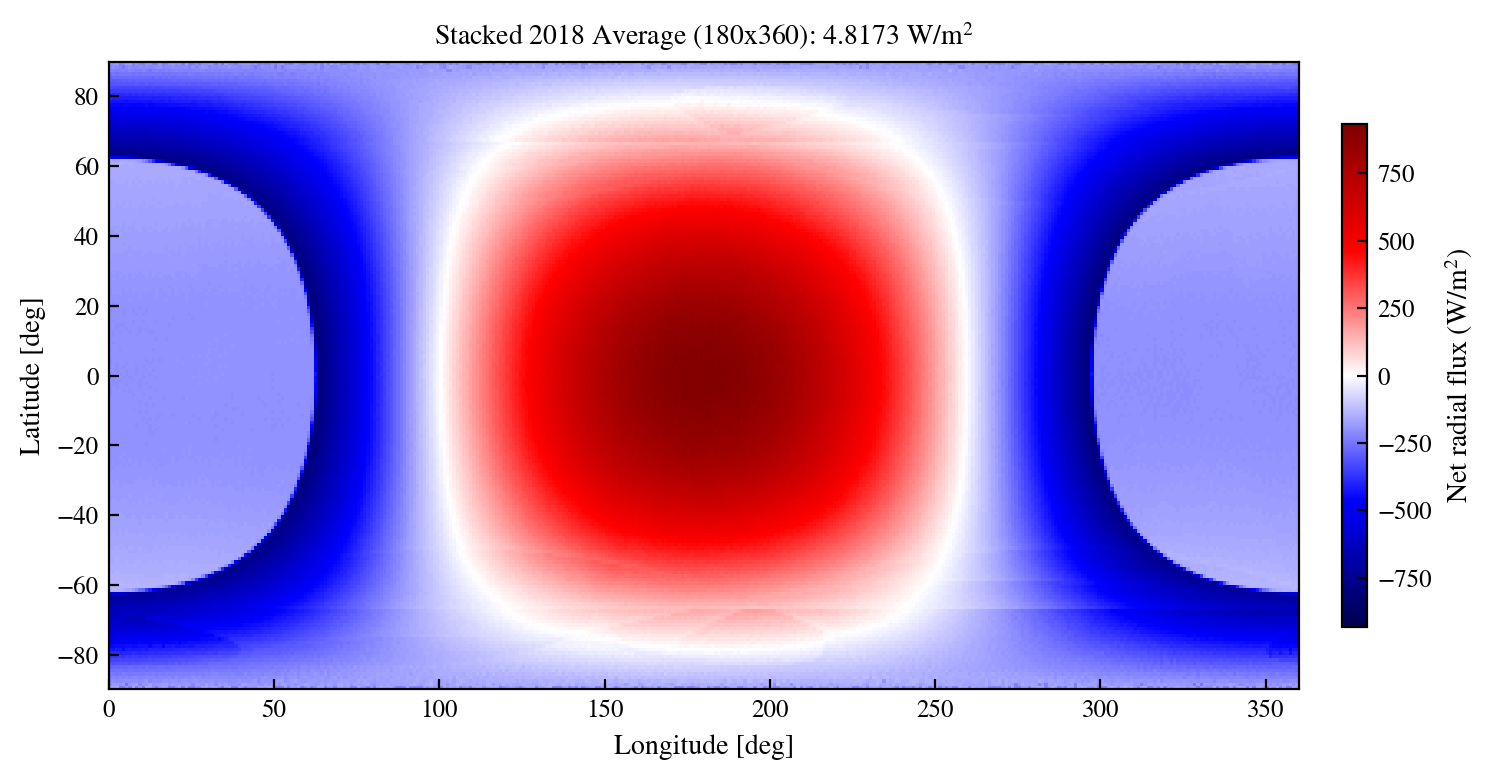

In [11]:
import numpy as np
from SpaceBalls.postproc_EEI_estimation import get_radial_measurement_arrays, get_full_output_var_hist, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode, fill_unobserved_cells_map_array_with_theta_s_fit_accurate
from SpaceBalls.sph_meshing import get_sphere_grid, get_reshaped_grid, get_spherical_grid_cell_areas
from SpaceBalls.radiation_fluxes_preprocessing import get_cos_theta_s_lim, get_mid_day_jd_array
from SpaceBalls.plotter import Plotter
import config.constants as constants
Re = constants.earth_radius(units='km')
EEI_name = "EEI_truth_1"
altitude = 800

SB_constellation = ['sc_C100', 'sc_C200', 'sc_C300']
input_names = ['case_5_years_' + sc_name for sc_name in SB_constellation]
frame = 'SFF'
frame_tag = '_SFF' if frame=="SFF" else ''

n_lon, n_lat = 360, 180
lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
full_lon_vec, full_lat_vec, _ = get_reshaped_grid(lon_vec, lat_vec)
areas = get_spherical_grid_cell_areas(lat_edges_vec, lon_edges_vec, R=Re+altitude)

mid_day_jd_array = get_mid_day_jd_array(EEI_name)
jd_windows = np.array([[mid_day_jd_array[0+i]- 0.5, mid_day_jd_array[365+i]+ 0.5] for i in range(1)])

jd_hist_array = get_full_output_var_hist(input_names, 'jd_vec')

radial_flux_meas_3D_arrays = get_radial_measurement_arrays(input_names, n_lon, n_lat, frame=frame, meas='flux') # this step takes significantly longer
avg_flux_maps = get_stacked_avg_maps_3D_mode(jd_windows, jd_hist_array, radial_flux_meas_3D_arrays) # this comes wiht unobserved cells

avg_flux_maps = fill_unobserved_cells_map_array_with_theta_s_fit_accurate(
    input_names, avg_flux_maps, jd_windows, get_cos_theta_s_lim(altitude), [False]*len(avg_flux_maps)) 


avg_0_toa = np.sum(avg_flux_maps[0] * areas) / (4 * np.pi * Re**2)

Plotter.plot_geo_data(avg_flux_maps[0], lon_edges_vec, lat_edges_vec, 
                        title=f"Stacked 2018 Average (180x360): {avg_0_toa:.4f} W/m$^2$", data_label='Net radial flux (W/m$^2$)')


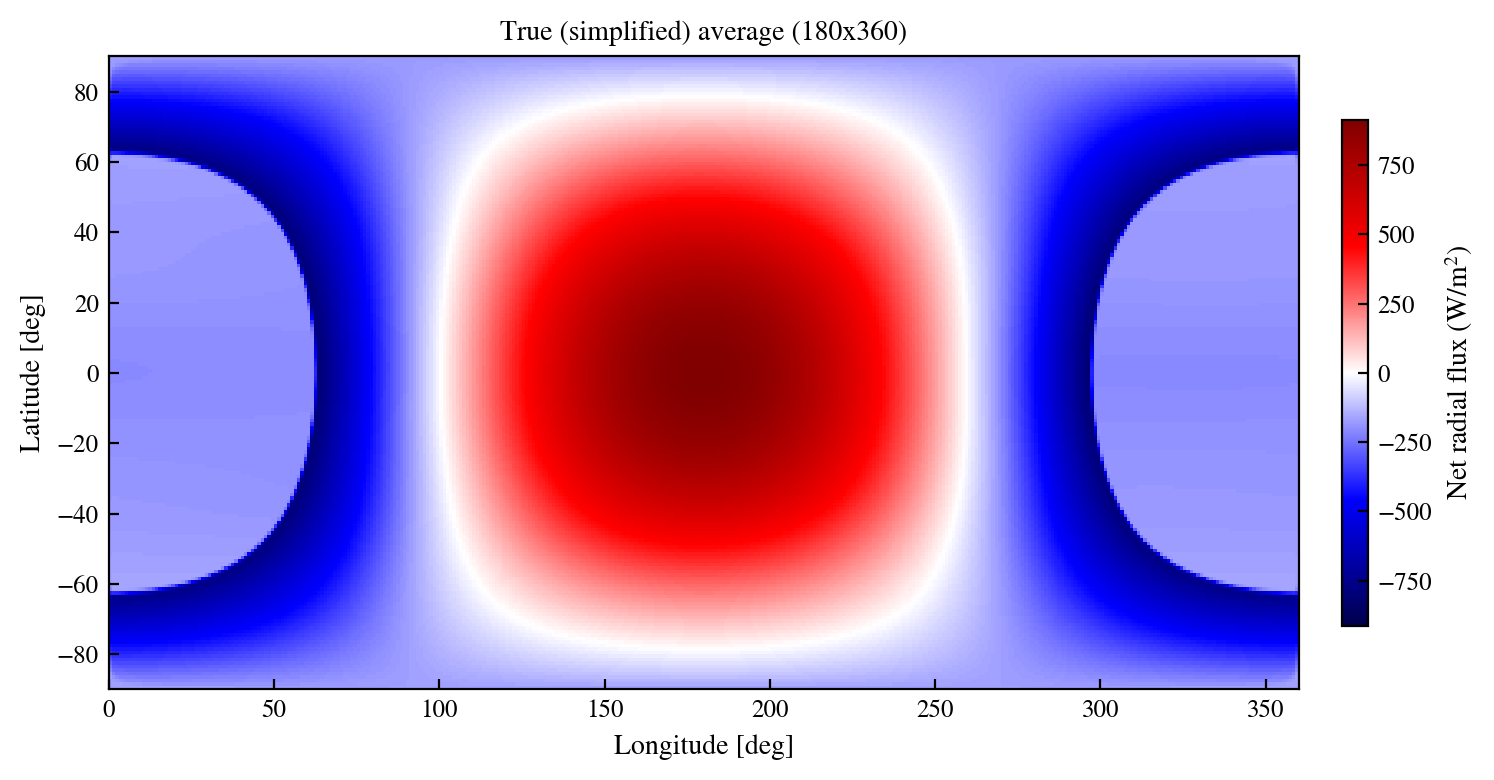

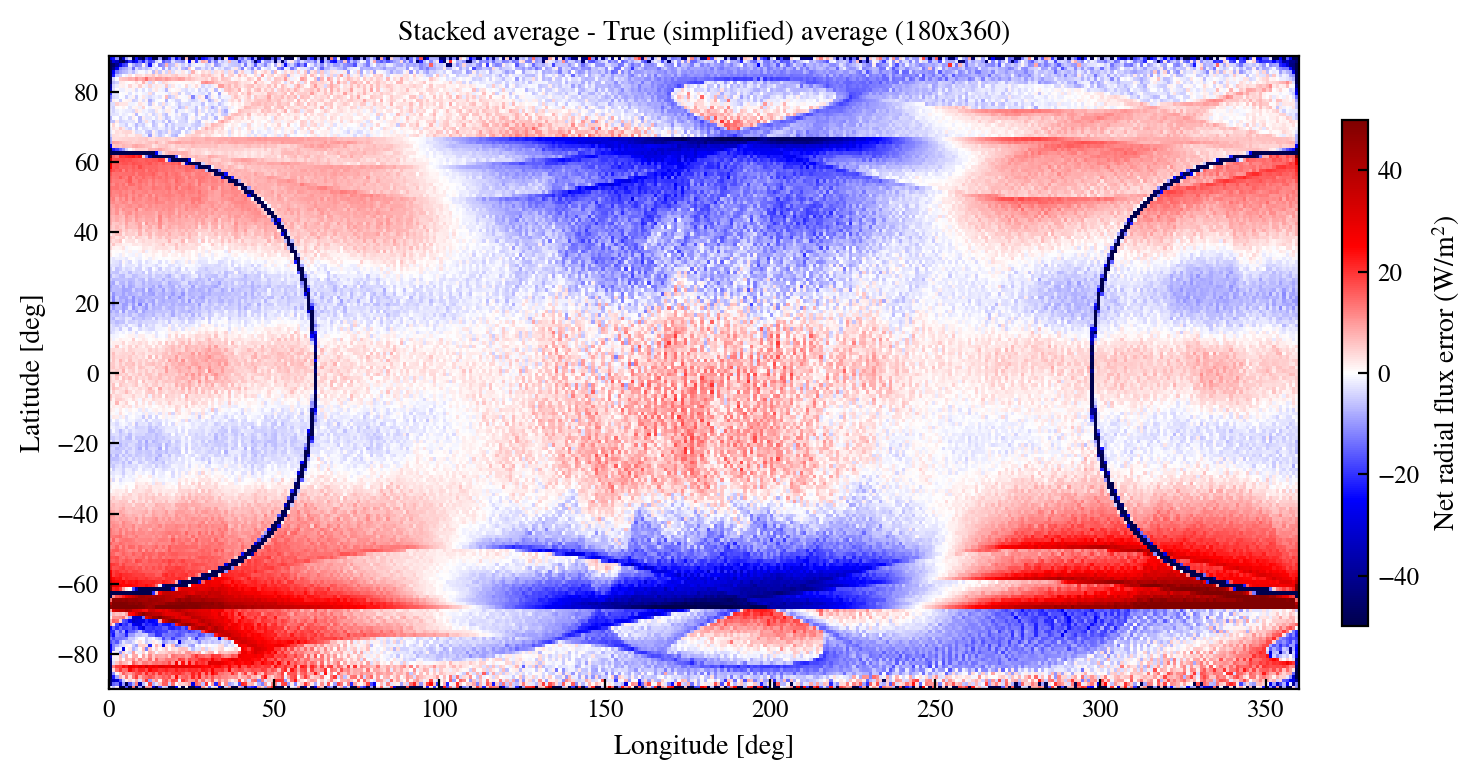

In [12]:
import sys, os
import numpy as np
from SpaceBalls.plotter import Plotter
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR
from SpaceBalls.sph_meshing import get_sphere_grid
from SpaceBalls.radiation_fluxes_preprocessing import get_file_names_and_existence, get_EEI_truth_daily_jd_arrays
%matplotlib inline

EEI_truth_name = "EEI_truth_1"
n_lon, n_lat = 360, 180
lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)

truth_dir = os.path.join(MEDIA_DIR, 'true_EEI', EEI_truth_name, 'grid_'+str(n_lat)+'x'+str(n_lon))
truth_jd_arrays = get_EEI_truth_daily_jd_arrays(EEI_truth_name)

for jd_window in jd_windows:
    idxs = [(jd_vec_day[0]>=jd_window[0] and jd_vec_day[1]<=jd_window[1]) for jd_vec_day in truth_jd_arrays]
    idxs = np.squeeze(np.argwhere(idxs))
    all_simpl_avgs = np.zeros((n_lat, n_lon, len(idxs)))
    
    for day_idx in idxs:
        file_names, file_existences = get_file_names_and_existence(truth_dir, 800, day_idx)

        #true_avg = np.load(os.path.join(truth_dir, file_names['daily_avg_net_800km']+'.npy'))
        all_simpl_avgs[:,:,day_idx] = np.load(os.path.join(truth_dir, file_names['daily_avg_net_800km_simpl1'+frame_tag]+'.npy'))

    true_simpl_avg = np.nanmean(all_simpl_avgs, axis=2)
    Plotter.plot_geo_data(true_simpl_avg, lon_edges_vec, lat_edges_vec, 
                        title=f"True (simplified) average (180x360)", 
                        data_label='Net radial flux (W/m$^2$)')

    stacked_avg_error = avg_flux_maps[0] - true_simpl_avg
    Plotter.plot_geo_data(stacked_avg_error, lon_edges_vec, lat_edges_vec, 
                        title=f"Stacked average - True (simplified) average (180x360)", 
                        data_label='Net radial flux error (W/m$^2$)', max_mag=50)